In [3]:
import pandas as pd
import os
import csv

# Lista de todos os ficheiros a processar
ficheiros = [
    "resumo_mitigacao_deepseek_v3.csv",
    "resumo_mitigacao_meta-llama_llama-3.1-8b-instruct.csv",
    "resumo_mitigacao_mistralai_mistral-7b-instruct.csv",
    "respostas_local_llama-3_1-8b.csv",
    "respostas_local_mistral-7b.csv",
    "respostas_local_gemma-3-4b.csv",
    "respostas_local_qwen-2_5-7b.csv"
]

def limpeza_total_excel(texto):
    if pd.isna(texto): return ""
    s = str(texto)
    # Remove qualquer tipo de quebra de linha (n, r, ou ambos)
    s = s.replace('\r\n', ' ').replace('\n', ' ').replace('\r', ' ')
    # Limpa espaços duplos e tabs
    return " ".join(s.split()).strip()

print("🧹 A processar limpeza e remoção de colunas vazias...")

for f in ficheiros:
    if os.path.exists(f):
        df = pd.read_csv(f)
        
        # 1. REMOVE COLUNAS TOTALMENTE VAZIAS (NaN)
        # axis=1 refere-se a colunas, how='all' significa "apagar se todos os valores forem nulos"
        df = df.dropna(axis=1, how='all')
        
        # 2. Limpar o conteúdo das colunas restantes
        for col in df.columns:
            df[col] = df[col].apply(limpeza_total_excel)
            
        # 3. Segunda verificação: remove colunas que ficaram vazias após a limpeza (apenas strings vazias)
        df = df.loc[:, (df != "").any(axis=0)]
        
        # Guardar com prefixo ORGANIZADO_
        df.to_csv(f"ORGANIZADO_{f}", 
                  sep=';', 
                  index=False, 
                  encoding='utf-8-sig', 
                  quoting=csv.QUOTE_ALL)
        
        print(f"✅ Corrigido e Filtrado: ORGANIZADO_{f} (Colunas restantes: {len(df.columns)})")

print("\n✨ Feito! Os ficheiros agora estão limpos e sem colunas inúteis.")

🧹 A processar limpeza e remoção de colunas vazias...
✅ Corrigido e Filtrado: ORGANIZADO_resumo_mitigacao_deepseek_v3.csv (Colunas restantes: 4)
✅ Corrigido e Filtrado: ORGANIZADO_resumo_mitigacao_meta-llama_llama-3.1-8b-instruct.csv (Colunas restantes: 5)
✅ Corrigido e Filtrado: ORGANIZADO_resumo_mitigacao_mistralai_mistral-7b-instruct.csv (Colunas restantes: 5)
✅ Corrigido e Filtrado: ORGANIZADO_respostas_local_llama-3_1-8b.csv (Colunas restantes: 7)
✅ Corrigido e Filtrado: ORGANIZADO_respostas_local_mistral-7b.csv (Colunas restantes: 7)
✅ Corrigido e Filtrado: ORGANIZADO_respostas_local_gemma-3-4b.csv (Colunas restantes: 7)
✅ Corrigido e Filtrado: ORGANIZADO_respostas_local_qwen-2_5-7b.csv (Colunas restantes: 7)

✨ Feito! Os ficheiros agora estão limpos e sem colunas inúteis.


In [3]:
pip install matplotlib seaborn numpy

  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 8.1/8.1 MB 41.8 MB/s  0:00:00
Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl (221 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 80.9 MB/s  0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ---------------------------------------- 7.1/7.1 MB 54.6 MB/s  0:00:00

   ---------------------------------------- 0/8 [pyparsing]
   ----- ---------------------------------- 1/8 [pillow]
   ----- ---------------------------------- 1/8 [pillow]
   ----- ---------------------------------- 1/8 [pillow]
   ----- ---------------------------------- 1/8 [pillow]
   ----- -----------------

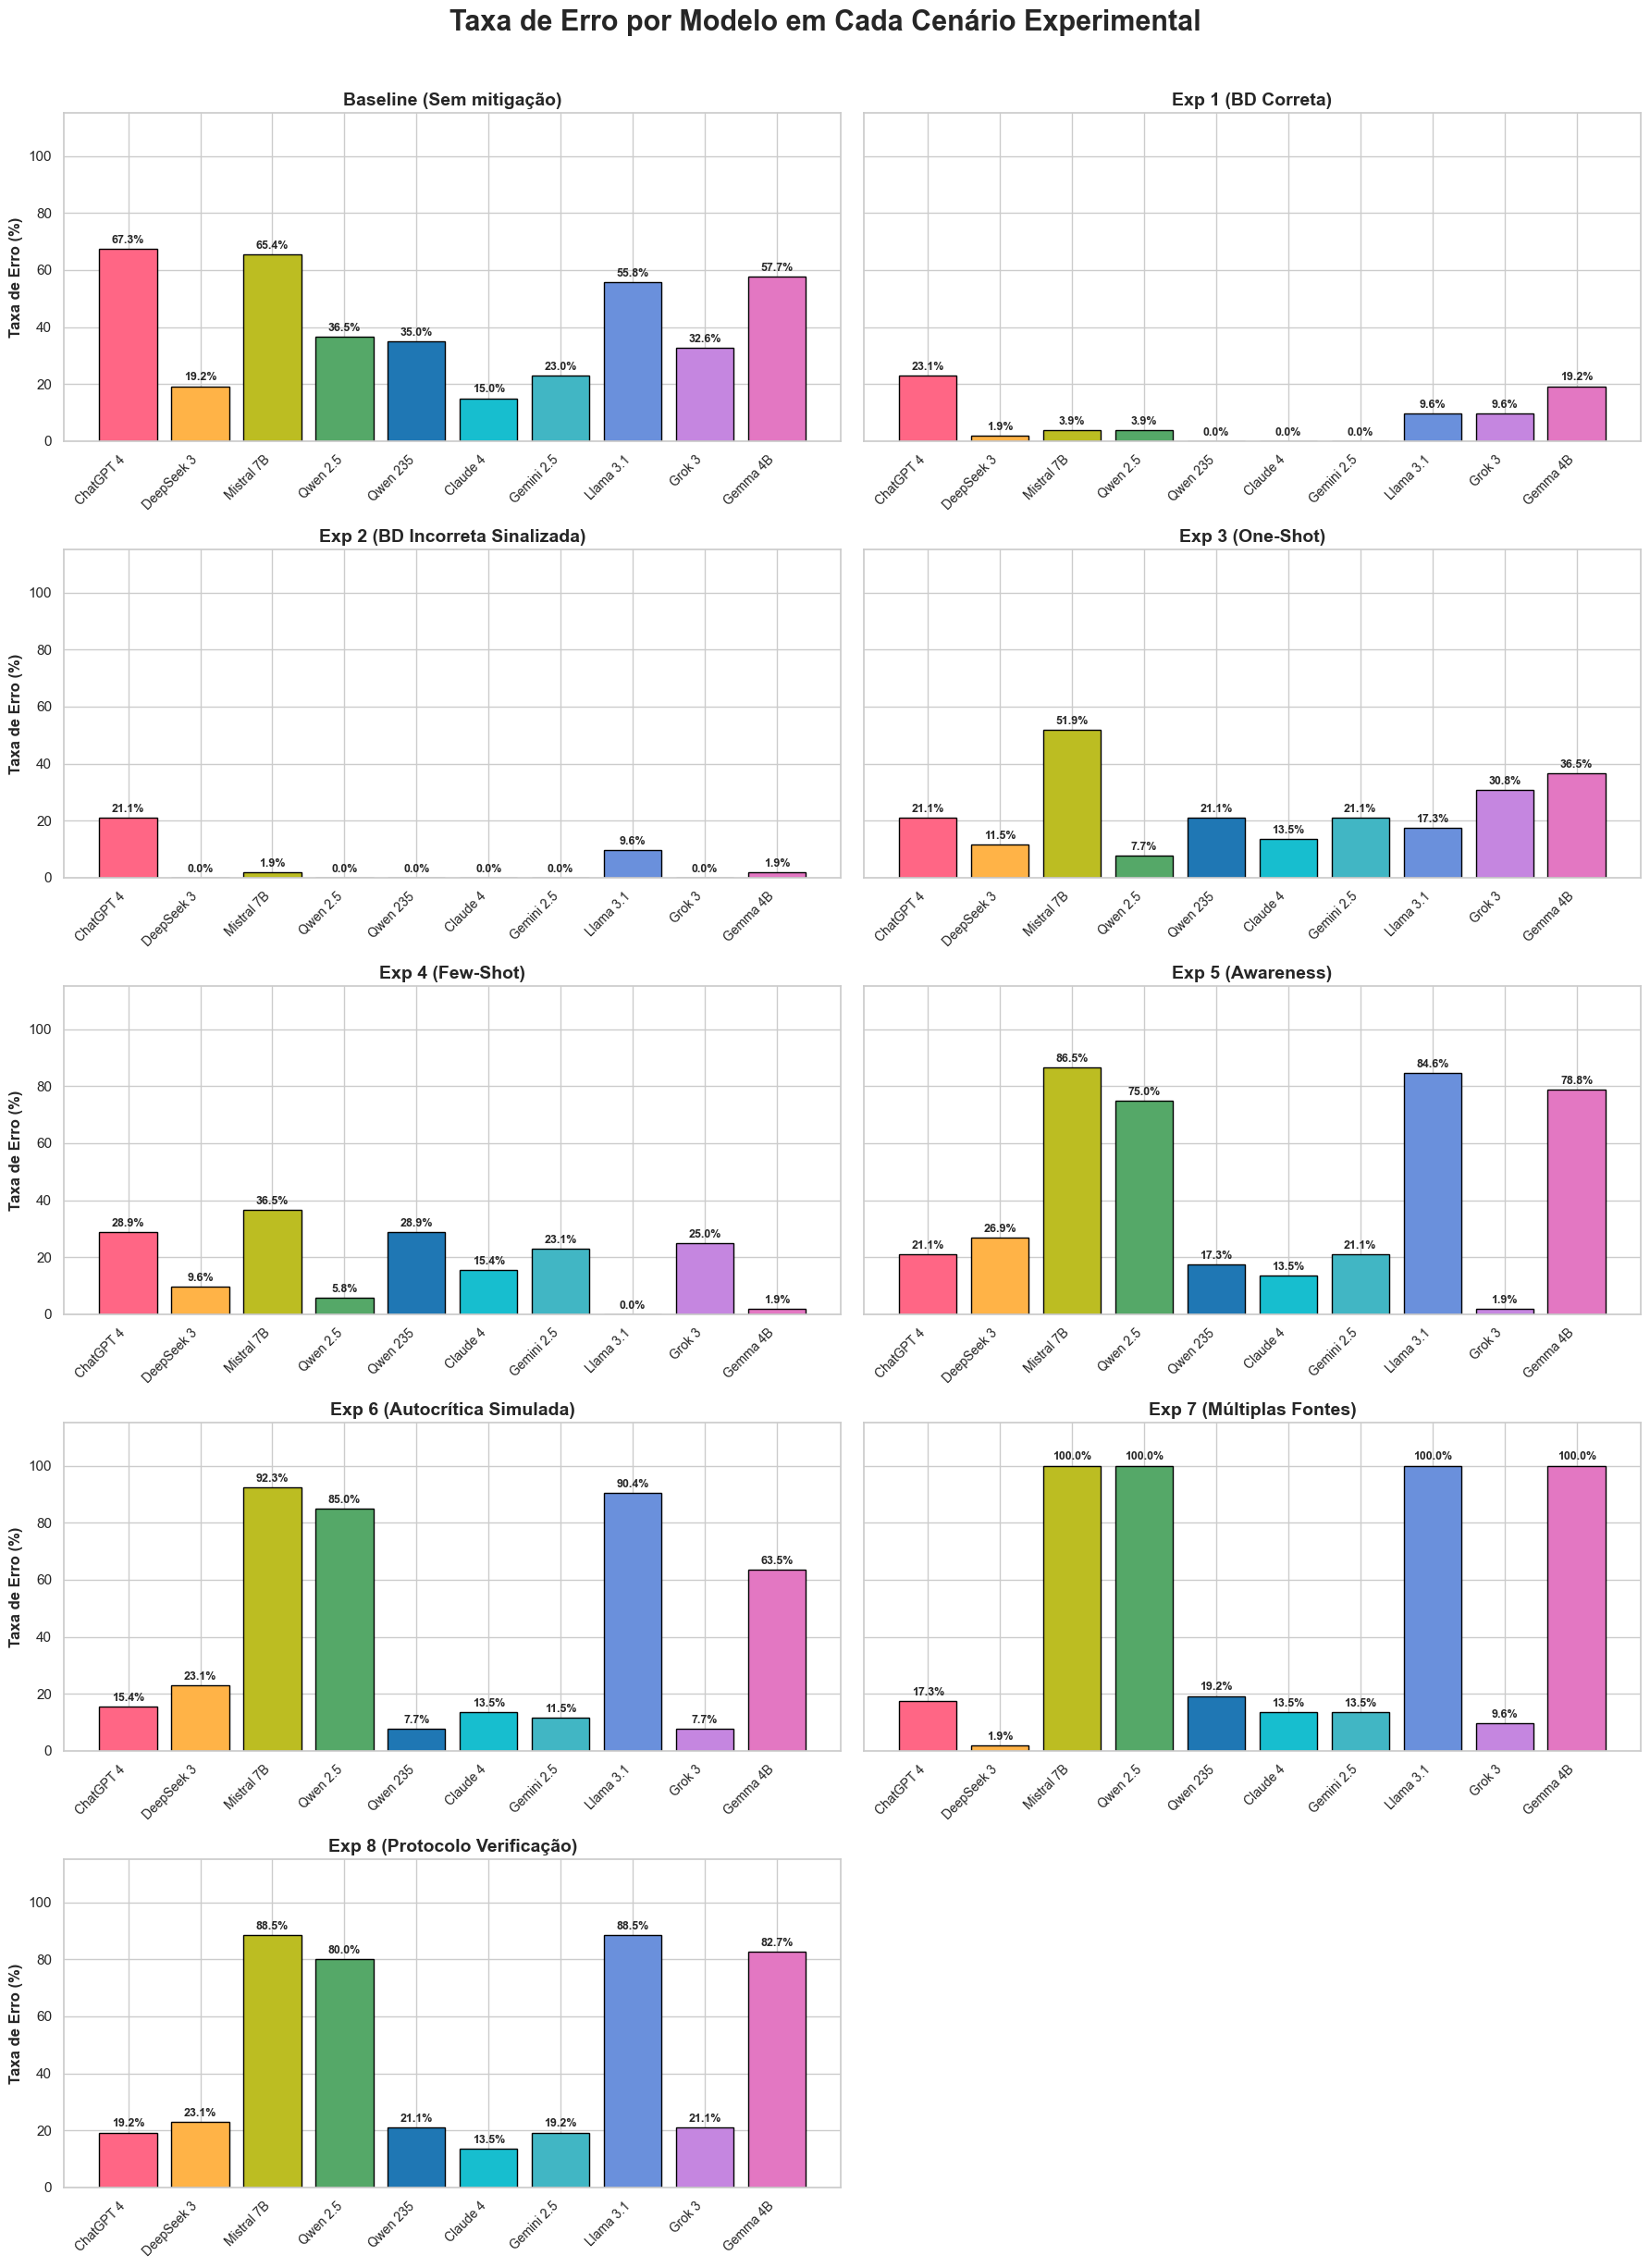

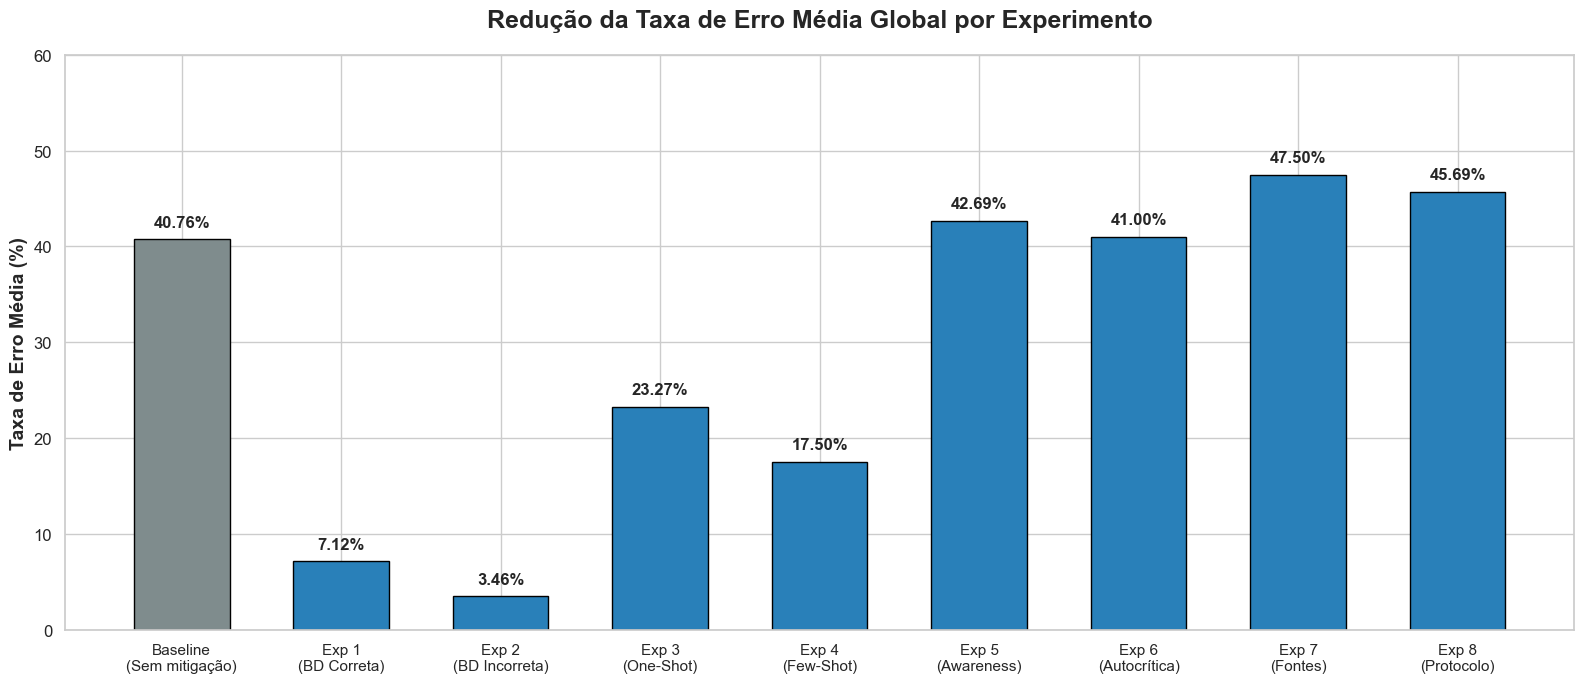

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Configuração de estilo
sns.set_theme(style="whitegrid")

# =====================================================================
# DADOS ATUALIZADOS (De acordo com a auditoria manual final do Excel)
# =====================================================================
modelos = ["ChatGPT 4", "DeepSeek 3", "Mistral 7B", "Qwen 2.5", "Qwen 235", 
           "Claude 4", "Gemini 2.5", "Llama 3.1", "Grok 3", "Gemma 4B"]

# Taxas de Erro (%)
baseline = [67.31, 19.23, 65.38, 36.54, 35.00, 15.00, 23.00, 55.77, 32.59, 57.69]
exp1 = [23.08, 1.92, 3.85, 3.85, 0.00, 0.00, 0.00, 9.62, 9.62, 19.23]
exp2 = [21.15, 0.00, 1.92, 0.00, 0.00, 0.00, 0.00, 9.62, 0.00, 1.92]
exp3 = [21.15, 11.54, 51.92, 7.69, 21.15, 13.46, 21.15, 17.31, 30.77, 36.54]
exp4 = [28.85, 9.60, 36.54, 5.77, 28.85, 15.38, 23.08, 0.00, 25.00, 1.92]
exp5 = [21.15, 26.92, 86.54, 75.00, 17.31, 13.46, 21.15, 84.61, 1.92, 78.85]
exp6 = [15.38, 23.08, 92.30, 85.00, 7.69, 13.46, 11.54, 90.38, 7.69, 63.46]
exp7 = [17.31, 1.92, 100.00, 100.00, 19.23, 13.46, 13.46, 100.00, 9.62, 100.00]
exp8 = [19.23, 23.08, 88.46, 80.00, 21.15, 13.46, 19.23, 88.46, 21.15, 82.69]

dados = [baseline, exp1, exp2, exp3, exp4, exp5, exp6, exp7, exp8]
titulos = [
    "Baseline (Sem mitigação)", "Exp 1 (BD Correta)", "Exp 2 (BD Incorreta Sinalizada)",
    "Exp 3 (One-Shot)", "Exp 4 (Few-Shot)", "Exp 5 (Awareness)",
    "Exp 6 (Autocrítica Simulada)", "Exp 7 (Múltiplas Fontes)", "Exp 8 (Protocolo Verificação)"
]

cores = ["#ff6685", "#ffb347", "#bcbd22", "#55a868", "#1f77b4", 
         "#17becf", "#41b6c4", "#6a90dc", "#c586e0", "#e377c2"]

# =====================================================================
# GRÁFICO 1: Matriz (5x2) - 2 gráficos por linha
# =====================================================================
# Alteramos para 5 linhas e 2 colunas
fig, axes = plt.subplots(5, 2, figsize=(18, 25), sharey=True) 
fig.suptitle('Taxa de Erro por Modelo em Cada Cenário Experimental', fontsize=22, fontweight='bold', y=0.98)

# Flatten axes para facilitar o loop (agora temos 10 espaços no total)
axes_flat = axes.flatten()

for i in range(len(dados)):
    ax = axes_flat[i]
    x = np.arange(len(modelos))
    bars = ax.bar(x, dados[i], color=cores, edgecolor='black')
    ax.set_title(titulos[i], fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(modelos, rotation=45, ha='right', fontsize=10)
    ax.set_ylim(0, 115) # Um pouco mais de folga para o texto
    
    # Adicionar labels no Eixo Y apenas na coluna da esquerda (índice par)
    if i % 2 == 0:
        ax.set_ylabel('Taxa de Erro (%)', fontsize=12, fontweight='bold')

    # Adicionar as percentagens no topo
    for bar in bars:
        altura = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., altura + 1,
                f'{altura:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Remover o último subplot (o 10º), já que só temos 9 conjuntos de dados
axes_flat[-1].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# =====================================================================
# GRÁFICO 2: Redução da Taxa de Erro Média Global por Experimento
# =====================================================================
labels_medias = [
    'Baseline\n(Sem mitigação)', 'Exp 1\n(BD Correta)', 'Exp 2\n(BD Incorreta)', 
    'Exp 3\n(One-Shot)', 'Exp 4\n(Few-Shot)', 'Exp 5\n(Awareness)', 
    'Exp 6\n(Autocrítica)', 'Exp 7\n(Fontes)', 'Exp 8\n(Protocolo)'
]

medias_globais = [40.76, 7.12, 3.46, 23.27, 17.50, 42.69, 41.00, 47.50, 45.69]

# Cores: Baseline a cinzento, restantes todos da mesma cor (ex: azul escuro)
cor_baseline = '#7f8c8d'
cor_experimentos = '#2980b9' 
bar_colors = [cor_baseline] + [cor_experimentos] * 8

fig2, ax2 = plt.subplots(figsize=(16, 7))

bars2 = ax2.bar(labels_medias, medias_globais, color=bar_colors, edgecolor='black', width=0.6)

# Configurar eixos e título
ax2.set_ylabel('Taxa de Erro Média (%)', fontsize=14, fontweight='bold')
ax2.set_title('Redução da Taxa de Erro Média Global por Experimento', fontsize=18, fontweight='bold', pad=20)
ax2.set_ylim(0, 60)
ax2.tick_params(axis='x', labelsize=11)
ax2.tick_params(axis='y', labelsize=12)

# Colocar as percentagens por cima de cada barra
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%', 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

# Sem caixa de legenda, apenas a legenda no eixo Y está presente
plt.tight_layout()
plt.show()